# Youtube Watch History Data Analysis

This is a simple exploratory data analysis project on my own Youtube watch history data (acquired from Google Takeout) from August to December 2025 using Python and the BeautifulSoup + NLTK packages. Some of the main questions include: 

- What are my most watched videos?
- Are there any recurring topics and keywords in those videos? 
- Are there any patterns of days or time in the day where I watch the most videos? 

## Reading in the data

In [2]:
#pip install lxml

In [3]:
#Importing the BeautifulSoup package
from bs4 import BeautifulSoup

import pandas as pd

In [4]:
#Use lxml instead of html.parser
with open("watch-history.html", encoding="utf-8") as f: 
    soup = BeautifulSoup(f, "lxml") 

#Printing title test
print(soup.title.text)

My Activity History


### Step 1: Extracting data from the html

After reading in the html file, the first step is to use BeautifulSoup package to scrape the useful information; in this case it is the watch history video link and all of the text in the main div that describes the video e.g., title, channel, date etc... This information is then stored in a Pandas data frame for further cleaning. 

In [5]:
#Body div with content info "content-cell mdl-cell mdl-cell--6-col mdl-typography--body-1"

info = soup.find_all(class_="content-cell mdl-cell mdl-cell--6-col mdl-typography--body-1")

links = []
for div in info:
    a = div.find("a", href=True)
    links.append(a["href"] if a else None) 

content_hist =  [div.get_text(separator="\n", strip = False) for div in info] 

In [6]:
uncleaned_df = pd.DataFrame(links, columns = ["URL"])
uncleaned_df["Content"] = content_hist

uncleaned_df

,URL,Content
0,https://www.youtube.com/watch?v=qziyMiO6Rew,Watched \nHow to Kill the Heart as Silent (Sla...
1,https://www.youtube.com/watch?v=O55A643t7Ps,Watched \nThe ending had me crying😭@doolybabyy...
2,https://www.youtube.com/watch?v=xKRd3bzzq24,"Watched \n#aestheic 💔\nibrownox\nDec 10, 2025,..."
3,https://www.youtube.com/watch?v=9Brrui2a_2o,Watched \ncrazy venom save #marvelrivals #mar...
4,https://www.youtube.com/watch?v=UTW-0gToLv4,Watched \nUrban Brew - Biodegradable Coffee Ca...
...,...,...
39695,https://www.youtube.com/watch?v=m2QpVJRnIpc,Watched \nCONQ^CC-long2^1080x1920^47#VD0000400...
39696,https://www.youtube.com/watch?v=-7jWEHOvRzE,Watched \nAnother Clip Ruined\nKartiFGC\nAug 4...
39697,https://www.youtube.com/watch?v=jVdPkc555u4,Watched \nBlurry: The Hypertension Study\nAug ...
39698,https://www.youtube.com/watch?v=8_yB4QcE4I0,Watched \nHere is how you can take 40 days off...


## Cleaning the data

### Step 2: Extracting the date/time column

Since all of the information is currently all stuck together in the content column, some cleaning is needed to split the information into clearer columns and make the data more usable. Starting with extracting the date and time into their own column using a combination of the rsplit and replace string methods as well as using the Pandas package to convert the column into a date time data type. 

In [7]:
#Date&Time is always formated in Content column after the last "\n" -> use rsplit and select [-1] index to extract datetime
uncleaned_df["datetime_str"] = uncleaned_df["Content"].str.rsplit("\n", n = 1).str[-1].str.replace("ACDT", "")
uncleaned_df["datetime"] = pd.to_datetime(uncleaned_df["datetime_str"], errors="coerce")
uncleaned_df

C:\Users\lambu\AppData\Local\Temp\ipykernel_28492\3546688934.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  uncleaned_df["datetime"] = pd.to_datetime(uncleaned_df["datetime_str"], errors="coerce")


,URL,Content,datetime_str,datetime
0,https://www.youtube.com/watch?v=qziyMiO6Rew,Watched \nHow to Kill the Heart as Silent (Sla...,"Dec 10, 2025, 7:47:59 PM",2025-12-10 19:47:59
1,https://www.youtube.com/watch?v=O55A643t7Ps,Watched \nThe ending had me crying😭@doolybabyy...,"Dec 10, 2025, 7:47:10 PM",2025-12-10 19:47:10
2,https://www.youtube.com/watch?v=xKRd3bzzq24,"Watched \n#aestheic 💔\nibrownox\nDec 10, 2025,...","Dec 10, 2025, 7:46:35 PM",2025-12-10 19:46:35
3,https://www.youtube.com/watch?v=9Brrui2a_2o,Watched \ncrazy venom save #marvelrivals #mar...,"Dec 10, 2025, 7:46:13 PM",2025-12-10 19:46:13
4,https://www.youtube.com/watch?v=UTW-0gToLv4,Watched \nUrban Brew - Biodegradable Coffee Ca...,"Dec 10, 2025, 7:46:12 PM",2025-12-10 19:46:12
...,...,...,...,...
39695,https://www.youtube.com/watch?v=m2QpVJRnIpc,Watched \nCONQ^CC-long2^1080x1920^47#VD0000400...,"Aug 4, 2025, 6:51:44 PM",2025-08-04 18:51:44
39696,https://www.youtube.com/watch?v=-7jWEHOvRzE,Watched \nAnother Clip Ruined\nKartiFGC\nAug 4...,"Aug 4, 2025, 6:51:40 PM",2025-08-04 18:51:40
39697,https://www.youtube.com/watch?v=jVdPkc555u4,Watched \nBlurry: The Hypertension Study\nAug ...,"Aug 4, 2025, 6:50:22 PM",2025-08-04 18:50:22
39698,https://www.youtube.com/watch?v=8_yB4QcE4I0,Watched \nHere is how you can take 40 days off...,"Aug 4, 2025, 5:31:13 PM",2025-08-04 17:31:13


### Step 3: Extracting the remaining information about videos in watch history

Similarly the next step also used the string split method splitting by the new line characters to extract the remaining information including video titles, channels, the action e.g., "Watched", "Viewed". 

In [8]:
split = uncleaned_df["Content"].str.split("\n", expand=True)
split[1]

uncleaned_df["Action"] = split[0]
uncleaned_df["Title"] = split[1]
uncleaned_df["Channel"] = split[2]

#Some videos don't have a channel, therefore some rows in the Channel column
# are accidentally filled in by the date due to how the split function works
#For loop through the Channel to change some of the misplaced dates to null values. 
for i in range(len(uncleaned_df)):
    value = uncleaned_df.loc[i, "Channel"]

    if value is not None and (
        "2025," in value or
        "2024," in value or
        "2023," in value
    ):
        uncleaned_df.loc[i, "Channel"] = None


uncleaned_df

,URL,Content,datetime_str,datetime,Action,Title,Channel
0,https://www.youtube.com/watch?v=qziyMiO6Rew,Watched \nHow to Kill the Heart as Silent (Sla...,"Dec 10, 2025, 7:47:59 PM",2025-12-10 19:47:59,Watched,How to Kill the Heart as Silent (Slay the Spir...,Baalorlord
1,https://www.youtube.com/watch?v=O55A643t7Ps,Watched \nThe ending had me crying😭@doolybabyy...,"Dec 10, 2025, 7:47:10 PM",2025-12-10 19:47:10,Watched,The ending had me crying😭@doolybabyyy #motivat...,Dooly.World1
2,https://www.youtube.com/watch?v=xKRd3bzzq24,"Watched \n#aestheic 💔\nibrownox\nDec 10, 2025,...","Dec 10, 2025, 7:46:35 PM",2025-12-10 19:46:35,Watched,#aestheic 💔,ibrownox
3,https://www.youtube.com/watch?v=9Brrui2a_2o,Watched \ncrazy venom save #marvelrivals #mar...,"Dec 10, 2025, 7:46:13 PM",2025-12-10 19:46:13,Watched,crazy venom save #marvelrivals #marvelrivalsc...,pinkiemelon
4,https://www.youtube.com/watch?v=UTW-0gToLv4,Watched \nUrban Brew - Biodegradable Coffee Ca...,"Dec 10, 2025, 7:46:12 PM",2025-12-10 19:46:12,Watched,Urban Brew - Biodegradable Coffee Capsules,None
...,...,...,...,...,...,...,...
39695,https://www.youtube.com/watch?v=m2QpVJRnIpc,Watched \nCONQ^CC-long2^1080x1920^47#VD0000400...,"Aug 4, 2025, 6:51:44 PM",2025-08-04 18:51:44,Watched,CONQ^CC-long2^1080x1920^47#VD000040039,None
39696,https://www.youtube.com/watch?v=-7jWEHOvRzE,Watched \nAnother Clip Ruined\nKartiFGC\nAug 4...,"Aug 4, 2025, 6:51:40 PM",2025-08-04 18:51:40,Watched,Another Clip Ruined,KartiFGC
39697,https://www.youtube.com/watch?v=jVdPkc555u4,Watched \nBlurry: The Hypertension Study\nAug ...,"Aug 4, 2025, 6:50:22 PM",2025-08-04 18:50:22,Watched,Blurry: The Hypertension Study,None
39698,https://www.youtube.com/watch?v=8_yB4QcE4I0,Watched \nHere is how you can take 40 days off...,"Aug 4, 2025, 5:31:13 PM",2025-08-04 17:31:13,Watched,Here is how you can take 40 days off with only...,size24


After extracting and cleaning the data all of the useful columns is assigned to a final dataframe named "df" to use as the dataframe for analysis. The date and time are also separated into their own columns. 

In [9]:

df = uncleaned_df[["URL", "Action", "Title", "Channel", "datetime"]]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39700 entries, 0 to 39699
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   URL       39569 non-null  object        
 1   Action    39700 non-null  object        
 2   Title     39700 non-null  object        
 3   Channel   32216 non-null  object        
 4   datetime  39700 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(4)
memory usage: 1.5+ MB


## Exploratory Data Analysis

### Part 1: Finding common video titles, tags and most watched channels

#### Figure 1: Channel Watch Count Table

Here, the data is grouped using the group by function in combination with the size function is then used to find out the most watched channelstched videos. 

In [10]:
channel_watch_count = df.groupby(["Channel"]).size().sort_values(ascending=False).reset_index(name="channel_watch_count")
channel_watch_count[(channel_watch_count["Channel"] != "") & (channel_watch_count["Channel"].notnull())].head(15)

,Channel,channel_watch_count
0,The Plant Slant,292
1,LoL Esports,241
2,CarterPCs,190
3,Naayil,181
4,HeWhoQuacksss,164
5,Azzapp LoL,148
7,Zach's Tech Turf,128
8,Kenshi Yonezu 米津玄師,127
9,Czokled,124
10,Ado,124


From the table there seems to be evidence of a spread out viewing pattern in terms of channels. After the top 3 most viewed channels, watch counts appear to gradually drop rather than a big fall; most channels in the top 15 lie around the 100-150 watch count range. This shows that from the period of August to Decemeber, I tend to spread my attention across a lot of different channels as opposed to having one or two dominant watches. 

By looking at the list of channel names, some clear content categories could be seen:
- **Gaming/Esports:** LoL Esports, Naayil, Azzapp LoL, Czokled, Agurin -> Esports channels and streamers 
- **Tech:** CarterPCs, Zach's Tech Turf 
- **Music Artists:** Ado, Kenshi Yonezu

seems to be the most dominant categories amongst the other more miscellaneous content. 

It is also important to note that these inferences are only made with the top 15 channels and not the full distribution. 

#### Figure 2: Table of Most Watched Videos

In [11]:
video_watch_count = df.groupby(["Title", "Channel"]).size().sort_values(ascending=False).reset_index(name="video_watch_count")
video_watch_count.head(15)

,Title,Channel,video_watch_count
0,【Ado】ギラギラ,Ado,36
1,【MV】BALALAIKA Acoustic Ver. / 9Lana,9Lana,25
2,"米津玄師, 宇多田ヒカル Kenshi Yonezu, Hikaru Utada - JA...",Kenshi Yonezu 米津玄師,22
3,Getting Started in Azure Synapse Analytics | A...,Alex The Analyst,22
4,lofi hip hop radio 📚 beats to relax/study to,Lofi Girl,16
5,natori - Propose,なとり / natori,15
6,#aestheic,PLEASE GANK,15
7,【MV】 「BALALAIKA」 / 9Lana,9Lana,14
8,🔴Live stream🔴,Chinese cuisine,14
9,#aestheic,I am Batpool,14


Similar to figure 1 this table shows the most watched videos instead of channels. There is less information to be deducted here, the top 15 list of most watched videos are alost entirely made up of music videos and few coding/math tutorials. This makes sense as these types of videos tend to have a higher rewatch value. 

##### Figure 2.1: Using NLTK to find common keywords and recurring phrases in video titles

Using the NLTK package each video title in the dataset is broken down into tokens stored as multiple items in a list assigned to a new column called tokens in the df data frame for easier analysis.

In [12]:
import nltk
nltk.download("stopwords") 
nltk.download("punkt")
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lambu\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lambu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [13]:
#Tokenising each title
df["tokens"] = df["Title"].str.lower().apply(nltk.word_tokenize) 
df["tokens"].head() 

C:\Users\lambu\AppData\Local\Temp\ipykernel_28492\1763927685.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["tokens"] = df["Title"].str.lower().apply(nltk.word_tokenize)


0    [how, to, kill, the, heart, as, silent, (, sla...
1    [the, ending, had, me, crying😭, @, doolybabyyy...
2                                     [#, aestheic, 💔]
3    [crazy, venom, save, #, marvelrivals, #, marve...
4    [urban, brew, -, biodegradable, coffee, capsules]
Name: tokens, dtype: object

Afterwards, in order to extract more useful information stopwords such as "a", "the", "is", etc... are removed from the tokens column. 

In [14]:
#Removing stopwords and unimportant tokens
import re

stopwords = set(stopwords.words("english"))

df["cleaned_tokens"] = df["tokens"].apply(
    lambda words: [w for w in words 
                   if w not in stopwords and re.match(r"[a-zA-z]+", w)]
)


Using the Counter function from the collections library, the top 20 most common tokens/keyword that appears in the Youtube Watch history is counted and shown below. 

In [15]:
from collections import Counter

word_counts = Counter()

for words in df["cleaned_tokens"]:
    word_counts.update(words)

word_counts.most_common(15)



[('shorts', 3745),
 ('https', 1214),
 ('blurry', 1147),
 ('vs', 1028),
 ('gaming', 997),
 ('leagueoflegends', 956),
 ('deadlock', 918),
 ('new', 836),
 ('best', 788),
 ('anime', 781),
 ('funny', 760),
 ('shortened', 666),
 ("n't", 664),
 ('overwatch', 635),
 ('one', 607)]

Similarly, using the string split method, different hashtags labels from the video titles were extracted and their frequencies counted using the Counter function. 

In [16]:
df["Video_Hastags"] = df["Title"].str.split("#").str[1:]


hashtag_counts = Counter()

for hashtags in df["Video_Hastags"]:
    cleaned = [h.strip() for h in hashtags] #Stripping each word before counting 
    hashtag_counts.update(cleaned)

hashtag_counts.most_common(15)

[('shorts', 3518),
 ('leagueoflegends', 932),
 ('gaming', 828),
 ('funny', 674),
 ('anime', 601),
 ('fyp', 502),
 ('overwatch2', 487),
 ('marvelrivals', 421),
 ('deadlock', 407),
 ('genshinimpact', 386),
 ('viral', 385),
 ('wutheringwaves', 376),
 ('edit', 341),
 ('memes', 304),
 ('wuwa', 289)]

### Part 2: Exploring time trends

Now using matplotlib and seaborn libraries some plots were made in order to show different time patterns in the watch history data. 

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns 

#### Figure 3 & 4: Videos Watched per Day of the Week/Month Bar Charts

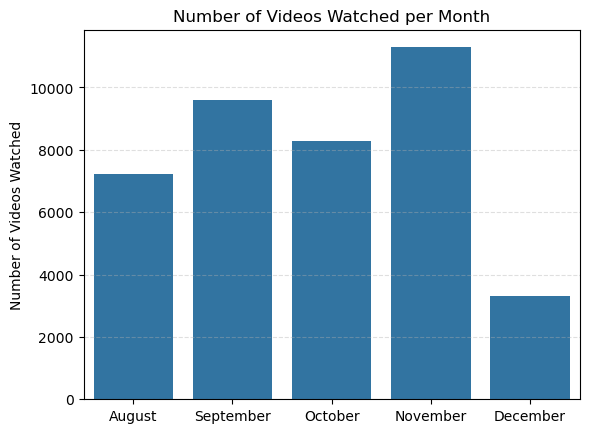

In [18]:
month_counts = df.groupby(df["datetime"].dt.month_name()).size().reindex([
    "August", "September", "October", "November", "December"
])

sns.barplot(x=month_counts.index, y=month_counts.values)

plt.title("Number of Videos Watched per Month")
plt.ylabel("Number of Videos Watched")
plt.xlabel(None)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

* The bar plot above is a slight increasing pattern on the number of videos watched per month from August to November
    * This generally aligns with university classes and holidays starting
    * August is around the middle of semester two where there was a larger density of classes and assignment whereas September was mainly spent finishing off assignments closing in on the end of the semester which could explain the slight increase in videos watched. 
    * October was mainly spent revising for exams and so there is a small dip in number of videos watched; additionally, exams finished early November which does align with the large spike in number of videos watched for the month. 
* The data does not capture all of December and so there is a misleadingly lower numbers of videos watched this month but from looking at the trend I expect this month will have the highest amount of videos watched as the holidays has fully settled in. 

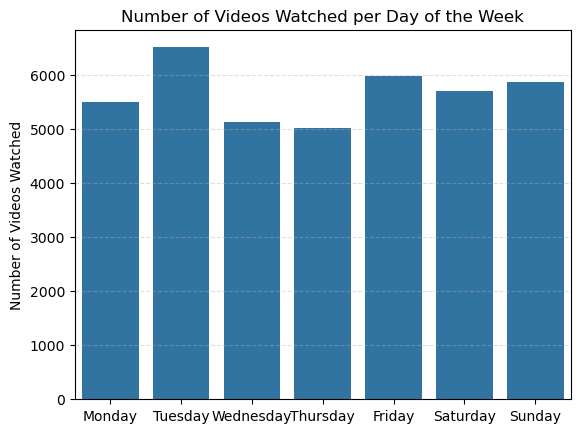

In [19]:

df["day_of_week"] = df["datetime"].dt.day_name()

day_counts = df.groupby("day_of_week").size().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)
sns.barplot(x=day_counts.index, y=day_counts.values)
plt.title("Number of Videos Watched per Day of the Week")
plt.ylabel("Number of Videos Watched")
plt.xlabel(None)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


* There does not seem to be a distinctly clear trend that can be deduced from the total number of movies watched on each day of the week shown above.
* There is a relatively even amount of videos watched daily though Tuesdays, Fridays and the weekends do seem to have consistently higher videos watched compared to the other days. This does make sense with the specific knowledge that these were the days which I specifically did not have many classes or spent most of my time at home. 

#### Figure 5 & 6: Line Plot of Total and Average Hourly Video Watch Count

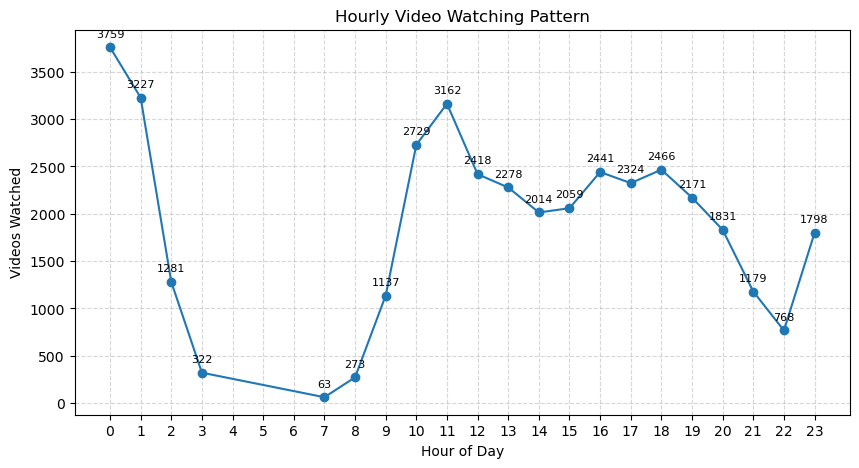

In [21]:
df["time_watched"] = df["datetime"].dt.hour

hour_counts = df.groupby("time_watched").size()

plt.figure(figsize=(10,5))
plt.plot(hour_counts.index, hour_counts.values, marker="o")

for x, y in zip(hour_counts.index, hour_counts.values):
    plt.annotate(str(y), xy=(x, y), xytext=(0, 6), textcoords="offset points", ha="center", va="bottom", fontsize=8)

plt.title("Hourly Video Watching Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Videos Watched")
plt.xticks(range(24))
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()


Above is a line plot showing how many videos was watched for each hour of the day.

* This plot at a first glance does outline my sleep schedule quite well, bewteen 3-8 AM where there are very little videos being watched compared to other hours of the day. 
* Throughout the day the amount of videos being watched at different hours is suprisingly consistent. 
    * There is a peak at 10-12 around lunch break time
    * The video watch count stays quite constant at around 2000-2500 videos between 1 and 6 PM. This can be explained by how I generally like to have videos or music playing in the background whilst I work. 
    * The watch count then goes on a constant fall bewteen 6 to 10 PM where there is dinner and various family activities that take place typically. 
    * Then there is a massive spike in watch count from 11PM to 1AM which does highlight a bad habit of binge watching videos before bed. 

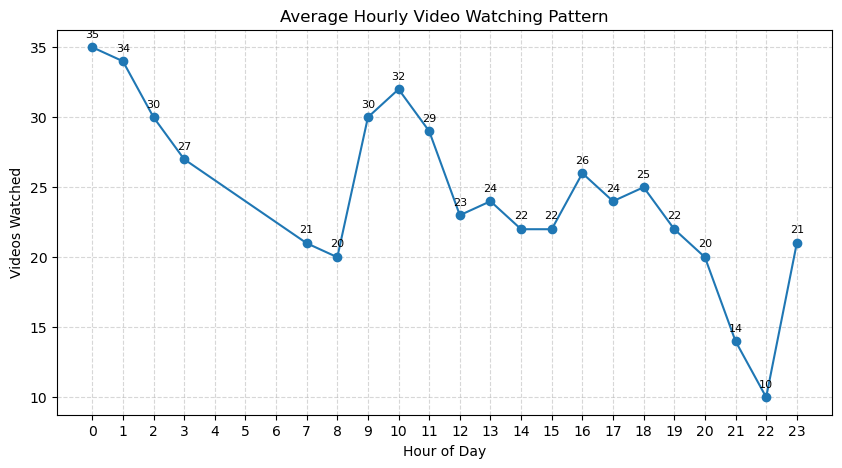

In [22]:
df["date_watched"] = df["datetime"].dt.date

hourly_counts = df.groupby(['date_watched', 'time_watched']).size()

avg_per_hour = hourly_counts.groupby('time_watched').mean().round().astype(int)

plt.figure(figsize=(10,5))
plt.plot(avg_per_hour.index, avg_per_hour.values, marker="o")

for x, y in zip(avg_per_hour.index, avg_per_hour.values):
    plt.annotate(str(y), xy=(x, y), xytext=(0, 6), textcoords="offset points", ha="center", va="bottom", fontsize=8)

plt.title("Average Hourly Video Watching Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Videos Watched")
plt.xticks(range(24))
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

This plot similar to the previous one tells a very similar story, a very clear midday lunch break followed by a steady afternoon of videos and a sharp decline at night with spikes in the early mornings.

#### Figure 7: Heatmap of Video Watching Activity by Day and Hour

In [27]:
heatmap_data = (
    df
    .groupby(["day_of_week", "time_watched"])
    .size()
    .reset_index(name="count")
    .pivot(index="day_of_week", columns="time_watched", values="count")
)


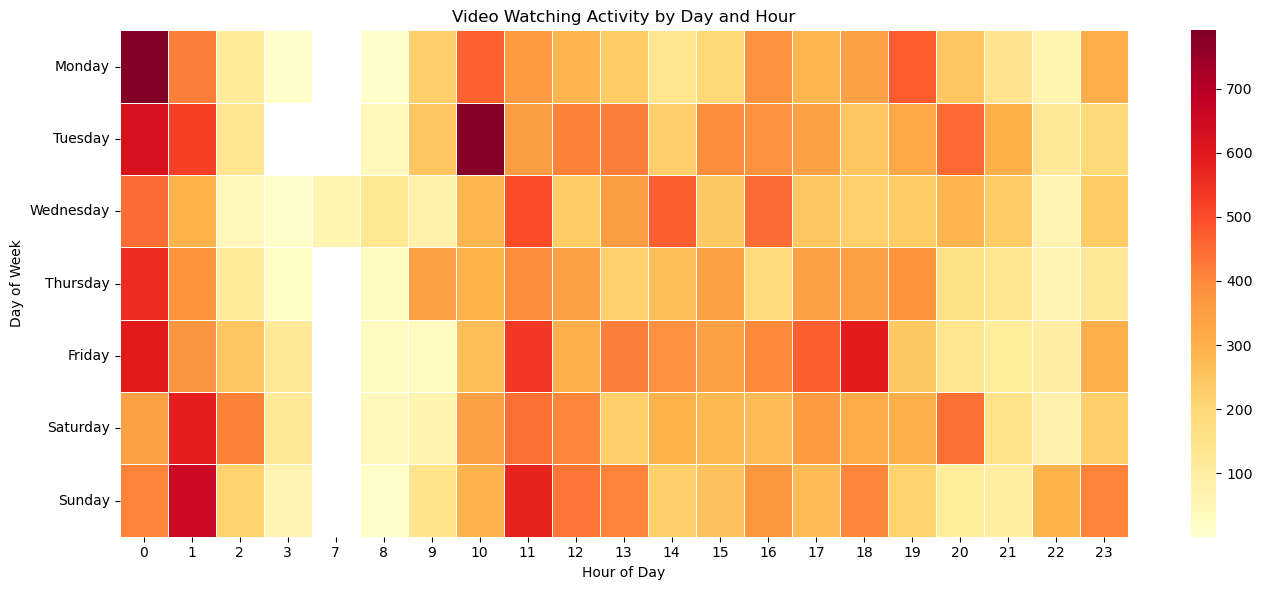

In [30]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Video Watching Activity by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

Similar to the previous plots, the heatmap above also shows video watch activity, however, it combines both the day of the week and the time of the day as elements of the plot in order to get a clearer visual of how all three variables interact. Again some points that this plot reiterates includes: 

* Consistently low video watching activity in the early morning around 3-8 AM on all days
    * Which corresponds with sleeping hours
* There is a strong viewing activity increase from late morning to afternoon from around 10AM - 6PM
* There are some viewing activity present in the evening however video watch counts start to spike considerably at late night and very early morning hours. 

The plot also vaguely indicates that weekend patterns do slightly differ from weekdays for example: 

* Viewing activity on Saturday is highest around 1AM then spikes again at around 8PM in the evening
* Sunday is slightly different with very high watch count at late nights and aside from sleeping hours the viewing activity stays some what consistent throughout the day and dips in the evening. 
    * This does show that weekend viewing times spread between Saturday and Sunday are more flexible and follow a less rigid routine compared to the weekdays. 

## Key Findings Summary

The exploratory data analysis showed with reasonable evidence that I tend to have a very clear and rigid pattern both when it comes to what I watch and when watch videos on Youtube. 

The consumption of videos is shown to be more concentrated among a smaller group of channels with the most watched channels being split bewteen gaming and music as the two dominant categories. Naturally the most viewed videos were the types of videos that had high rewatchability such as guides or music videos. Similarly, the most commonly appearing words or hastags in the video titles all made intuitive sense. Excluding common stop words such as "the", "a", or "and" the most commonly occuring words were generic tags such as "funny", "gaming", "anime", or various video game titles. 

The data analysis also revealed that my video comsumption behaviour consistently structured and follows and rather clear schedule. Observations showed a clear daily rhythm with very strong late night peaks in activity, consistent mid-day viewing and very low watch counts in the morning. As shown in the heatmap, Figure 7, there may also be a small difference between weekend and weekday video viewing patterns. 
